# Gradient Boosting
## Topic: Customer Churn Prediction
### Reference: GeeksforGeeks + Original Notes

---

## 1. What is Gradient Boosting?

> **GeeksforGeeks Definition:** Gradient Boosting is a **boosting algorithm** where each new model is trained to **minimize the loss function** (such as MSE or cross-entropy) of the previous model using **gradient descent**.

**Real-life analogy:**
```
You take an exam and score 60/100.
Teacher marks your MISTAKES specifically.
You study only those mistakes → score 75/100.
Teacher marks NEW mistakes → you study those → score 85/100.
Repeat until near perfect.

Gradient Boosting = each new tree studies ONLY the mistakes of all previous trees.
```

Unlike Random Forest (parallel trees), Gradient Boosting builds trees **one by one** — each tree tries to fix what the previous ones got wrong.

---

## 2. Boosting vs Bagging — The Core Difference

```
BAGGING (Random Forest)              BOOSTING (Gradient Boosting)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Trees built in PARALLEL              Trees built SEQUENTIALLY
Each tree INDEPENDENT                Each tree CORRECTS previous errors
Train on bootstrap samples           Train on RESIDUALS of prior trees
Reduces VARIANCE                     Reduces BIAS
Hard to overfit                      CAN overfit — needs tuning
Fast (parallelizable)                Slower (must be sequential)
```

---

## 3. How Gradient Boosting Works — Step by Step (GFG)

```
Dataset: 5 customers, actual churn risk = [0.8, 0.2, 0.9, 0.1, 0.6]

STEP 1: Make initial prediction
  → Predict the mean of all targets: ŷ = 0.52 for every sample
  → Residuals = Actual - Predicted
                = [0.28, -0.32, 0.38, -0.42, 0.08]

STEP 2: Train Tree 1 on RESIDUALS (not original labels!)
  → Tree 1 predicts residuals: [0.25, -0.30, 0.35, -0.40, 0.10]
  → Update predictions: ŷ_new = ŷ_old + learning_rate × Tree1_preds
                               = 0.52 + 0.1 × [0.25, -0.30, ...]
  → New residuals = Actual - ŷ_new  (smaller than before!)

STEP 3: Train Tree 2 on NEW residuals
  → Each tree corrects the remaining error
  → Residuals keep shrinking

STEP N: Final prediction
  → ŷ_final = Initial + η×Tree1 + η×Tree2 + ... + η×TreeN
  → where η (eta) = learning_rate
```

**Final prediction formula (GFG):**
```
y_pred = y₁ + η·r₁ + η·r₂ + η·r₃ + ... + η·rₙ

where:
  y₁ = initial prediction (mean for regression, log-odds for classification)
  rₙ = n-th tree's prediction of residuals
  η  = learning rate (shrinkage) — typically 0.01 to 0.2
```

---

## 4. What Are Residuals?

**Residual = Actual value − Predicted value**

```
Iteration 1:
  Customer A: Actual=0.8, Predicted=0.52  → Residual = +0.28  (under-predicted)
  Customer B: Actual=0.2, Predicted=0.52  → Residual = -0.32  (over-predicted)

Tree 1 trains on these residuals as its target labels
→ Tree 1 learns to push A up and B down

Iteration 2:
  Customer A: Predicted=0.545, Residual = +0.255  (smaller!)
  Customer B: Predicted=0.487, Residual = -0.287  (smaller!)

Each iteration, residuals shrink → model improves
```

---

## 5. The Gradient Descent Connection

Why is it called **Gradient** Boosting?

```
In regular Gradient Descent (neural networks):
  Update weights in the direction of -∇Loss
  weights = weights - learning_rate × gradient

In Gradient Boosting:
  Update predictions in the direction of -∇Loss
  predictions = predictions + learning_rate × new_tree

For MSE loss: gradient = -(Actual - Predicted) = -residual
→ Fitting residuals IS doing gradient descent in function space!

For other losses (log-loss, MAE): gradient takes a different form
→ Each tree fits the NEGATIVE GRADIENT of the loss, not raw residuals
```

This is why Gradient Boosting works for any differentiable loss function — it is **gradient descent in function space**.

---

## 6. Key Terminology

| Term | Meaning |
|------|---------|
| Weak learner | A simple model (usually shallow tree, depth=1-3) that is only slightly better than random |
| Residual | Actual − Predicted — the error each next tree tries to correct |
| Shrinkage / Learning rate (η) | Scale factor applied to each tree's contribution — prevents overfitting |
| Pseudo-residual | Negative gradient of loss — generalization of residuals for any loss function |
| n_estimators | Number of trees (boosting rounds) |
| Subsampling | Using a random fraction of rows per tree (like Bagging) — reduces variance |
| loss | The loss function to minimize: 'log_loss' (classif.), 'squared_error' (regression) |

---

## 7. Learning Rate — The Most Important Parameter

**Learning rate η (shrinkage)** controls how much each tree contributes.

```
HIGH learning rate (e.g., η=0.5):
  + Fewer trees needed
  − Overshoots → overfitting, unstable

LOW learning rate (e.g., η=0.01):
  + More conservative, better generalization
  − Needs many more trees (slow training)

RULE OF THUMB (GFG): η × n_estimators should be constant
  If you halve learning_rate → double n_estimators for same accuracy
  Typical: learning_rate=0.05 to 0.1, n_estimators=100 to 500
```

**Learning rate vs n_estimators tradeoff:**
| | Low LR + Many Trees | High LR + Few Trees |
|-|---------------------|---------------------|
| Accuracy | Higher | Lower |
| Overfitting | Less likely | More likely |
| Training speed | Slow | Fast |
| Recommendation | Production | Prototyping |

---

## 8. Gradient Boosting vs AdaBoost (GFG)

Both are boosting methods but differ in HOW they correct errors:

| Aspect | AdaBoost | Gradient Boosting |
|--------|----------|-----------------|
| Error correction | Re-weights misclassified samples | Fits residuals (negative gradient) |
| Base learners | Decision stumps (depth=1) | Shallow trees (depth=1-5) |
| Loss function | Classification error only | Any differentiable loss |
| Noise sensitivity | High | Lower (gradient smoothing) |
| Interpretability | Easier | More complex |
| Use cases | Clean datasets | Complex/noisy problems |

---

## 9. Overfitting in Gradient Boosting

Gradient Boosting CAN overfit — unlike Random Forest, more trees is NOT always better.

| Cause | Effect | Fix |
|-------|--------|-----|
| Too many trees | Memorizes training data | Reduce n_estimators or use early stopping |
| High learning rate | Aggressive fitting | Lower learning_rate |
| Deep trees | Complex individual models | Reduce max_depth (keep it 3-5) |
| No subsampling | Uses all data each tree | Set subsample=0.8 |

**Early stopping** — stop adding trees when validation error stops improving:
```python
# sklearn does not natively support early stopping in GBM
# Use staged_predict to find optimal n_estimators
errors = [loss for loss in gbm.staged_predict(X_val)]
optimal_n = np.argmin(errors) + 1
```

---

## 10. Advantages and Disadvantages (GFG)

### Advantages
| # | Advantage | Detail |
|---|-----------|--------|
| 1 | High predictive accuracy | Often wins on tabular data competitions |
| 2 | Flexible loss functions | Works for regression, classification, ranking |
| 3 | Less sensitive to noise than AdaBoost | Gradient smoothing helps |
| 4 | Handles mixed data types | No feature scaling needed |
| 5 | Feature importance | Built-in MDI importance |
| 6 | Handles outliers better than Linear models | Tree-based splits are robust |

### Disadvantages (GFG)
| # | Disadvantage | Fix |
|---|-------------|-----|
| 1 | Sequential → slow training | Use XGBoost/LightGBM instead |
| 2 | Sensitive to hyperparameters | Requires careful tuning |
| 3 | Can overfit with high learning rate | Lower learning_rate |
| 4 | Memory intensive | Reduce n_estimators, max_depth |
| 5 | Not interpretable | Use feature importance or SHAP |

---

## 11. Key Parameters

| Parameter | Default | Controls | Tip |
|-----------|---------|----------|-----|
| `n_estimators` | 100 | Number of trees | More trees + lower LR = better |
| `learning_rate` | 0.1 | Shrinkage per tree | Start 0.05-0.1; lower = better generalization |
| `max_depth` | 3 | Depth of each tree | Keep 3-5; deeper = more overfit risk |
| `subsample` | 1.0 | Fraction of samples per tree | 0.8 reduces variance |
| `max_features` | None | Features per split | 'sqrt' or 0.8 reduces variance |
| `min_samples_leaf` | 1 | Min samples in leaf | Increase on noisy data |
| `loss` | 'log_loss' | Loss function | 'log_loss' for classif., 'squared_error' for regression |
| `warm_start` | False | Reuse previous fit | Set True to incrementally add trees |

---

## 12. Real-World Applications

| Domain | Use Case |
|--------|----------|
| Finance | Credit scoring, fraud detection |
| E-commerce | Click-through rate prediction, ranking |
| Healthcare | Disease risk scoring |
| Telecom | Churn prediction |
| Kaggle | Wins many tabular data competitions |
| Search | Web page ranking (Learning to Rank) |

---
# Implementation: Customer Churn Prediction
---

In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    AdaBoostClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.datasets import load_breast_cancer, load_diabetes
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Step 2: Create Customer Churn Dataset
np.random.seed(42)
n_churn, n_stay = 150, 300

churn = {
    'tenure_months':     np.random.randint(1, 18, n_churn),
    'monthly_charges':   np.random.uniform(70, 120, n_churn),
    'num_products':      np.random.randint(1, 3, n_churn),
    'has_tech_support':  np.random.choice([0,1], n_churn, p=[0.75,0.25]),
    'contract_type':     np.random.choice([0,1,2], n_churn, p=[0.70,0.20,0.10]),
    'payment_method':    np.random.choice([0,1,2,3], n_churn),
    'num_support_calls': np.random.randint(3, 10, n_churn),
    'label': [1]*n_churn
}
stay = {
    'tenure_months':     np.random.randint(12, 72, n_stay),
    'monthly_charges':   np.random.uniform(40, 85, n_stay),
    'num_products':      np.random.randint(2, 5, n_stay),
    'has_tech_support':  np.random.choice([0,1], n_stay, p=[0.30,0.70]),
    'contract_type':     np.random.choice([0,1,2], n_stay, p=[0.20,0.40,0.40]),
    'payment_method':    np.random.choice([0,1,2,3], n_stay),
    'num_support_calls': np.random.randint(0, 4, n_stay),
    'label': [0]*n_stay
}

df = pd.concat([pd.DataFrame(churn), pd.DataFrame(stay)],
               ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

features = ['tenure_months','monthly_charges','num_products',
            'has_tech_support','contract_type','payment_method','num_support_calls']
X, y = df[features], df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dataset: {df.shape} | Train: {X_train.shape} | Test: {X_test.shape}')
print(df['label'].value_counts().rename({0:'Stayed',1:'Churned'}))

Dataset: (450, 8) | Train: (360, 7) | Test: (90, 7)
Stayed     300
Churned    150
Name: label, dtype: int64


In [3]:
# Step 3: Residuals Demo — How GBM Corrects Errors Iteration by Iteration
print('=' * 62)
print('RESIDUALS DEMO — How Gradient Boosting Corrects Errors (GFG)')
print('=' * 62)

# Use a tiny regression-like example for clarity
actual   = np.array([0.8, 0.2, 0.9, 0.1, 0.6])
names    = ['Alice','Bob','Carol','Dave','Eve']

# Iteration 0: predict the mean
pred = np.full(len(actual), actual.mean())
print(f'\nInitial prediction (mean): {pred[0]:.3f} for all')
print(f'{"Customer":<8} {"Actual":>8} {"Pred_0":>8} {"Resid_0":>10}')
print('-' * 40)
for n, a, p in zip(names, actual, pred):
    print(f'{n:<8} {a:>8.3f} {p:>8.3f} {a-p:>10.3f}')

lr = 0.5
for iteration in range(1, 4):
    residuals = actual - pred
    # Simulate a weak tree by predicting mean of residuals per half
    tree_pred = residuals * 0.6  # simplified approximation
    pred = pred + lr * tree_pred
    new_resid = actual - pred
    print(f'\nAfter Tree {iteration} (lr={lr}):')
    print(f'{"Customer":<8} {"Actual":>8} {"Pred":>8} {"Residual":>10} {"Improvement":>12}')
    print('-' * 52)
    for i, (n, a, p) in enumerate(zip(names, actual, pred)):
        print(f'{n:<8} {a:>8.3f} {p:>8.3f} {new_resid[i]:>10.3f}')

print(f'\nFinal MSE: {np.mean((actual-pred)**2):.4f}')
print('Note: residuals shrink each iteration — model gets progressively better')

RESIDUALS DEMO — How Gradient Boosting Corrects Errors (GFG)

Initial prediction (mean): 0.520 for all
Customer   Actual   Pred_0    Resid_0
----------------------------------------
Alice       0.800    0.520      0.280
Bob         0.200    0.520     -0.320
Carol       0.900    0.520      0.380
Dave        0.100    0.520     -0.420
Eve         0.600    0.520      0.080

After Tree 1 (lr=0.5):
Customer   Actual     Pred   Residual  Improvement
----------------------------------------------------
Alice       0.800    0.604      0.196
Bob         0.200    0.424     -0.224
Carol       0.900    0.634      0.266
Dave        0.100    0.394     -0.294
Eve         0.600    0.544      0.056

After Tree 2 (lr=0.5):
Customer   Actual     Pred   Residual  Improvement
----------------------------------------------------
Alice       0.800    0.663      0.137
Bob         0.200    0.357     -0.157
Carol       0.900    0.714      0.186
Dave        0.100    0.306     -0.206
Eve         0.600    0.561    

In [4]:
# Step 4: Train GBM and Compare with Single Tree & Random Forest
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

for model in [dt, rf, gbm, ada]:
    model.fit(X_train, y_train)

print('=' * 65)
print('MODEL COMPARISON: DT vs RF (Bagging) vs GBM vs AdaBoost (Boosting)')
print('=' * 65)
print(f'\n{"Model":<35} {"Train":>8} {"Test":>8} {"ROC-AUC":>10}')
print('-' * 65)

for name, model in [
    ('Decision Tree (Depth=5)',     dt),
    ('Random Forest — Bagging',     rf),
    ('Gradient Boosting — Boosting',gbm),
    ('AdaBoost — Boosting',         ada),
]:
    tr  = accuracy_score(y_train, model.predict(X_train))
    te  = accuracy_score(y_test,  model.predict(X_test))
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    flag = ' <- overfit' if (tr-te) > 0.1 else ''
    print(f'{name:<35} {tr:>8.1%} {te:>8.1%} {auc:>10.4f}{flag}')

MODEL COMPARISON: DT vs RF (Bagging) vs GBM vs AdaBoost (Boosting)

Model                                  Train     Test    ROC-AUC
-----------------------------------------------------------------
Decision Tree (Depth=5)               100.0%    98.9%     0.9917
Random Forest — Bagging               100.0%   100.0%     1.0000
Gradient Boosting — Boosting          100.0%   100.0%     1.0000
AdaBoost — Boosting                   100.0%   100.0%     1.0000


In [5]:
# Step 5: Learning Rate Effect — Low LR needs More Trees (GFG)
lr_configs = [
    (0.5,  20,  'High LR, Few Trees'),
    (0.1,  100, 'Medium LR, Moderate Trees'),
    (0.05, 200, 'Low LR, Many Trees'),
    (0.01, 500, 'Very Low LR, Many Trees'),
]

print('Learning Rate vs n_estimators Tradeoff (GFG)')
print('=' * 65)
print(f'{"Config":<35} {"Train":>8} {"Test":>8} {"ROC-AUC":>10}')
print('-' * 65)

for lr, n, label in lr_configs:
    m = GradientBoostingClassifier(learning_rate=lr, n_estimators=n, max_depth=3, random_state=42)
    m.fit(X_train, y_train)
    tr  = accuracy_score(y_train, m.predict(X_train))
    te  = accuracy_score(y_test,  m.predict(X_test))
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    print(f'{label:<35} {tr:>8.1%} {te:>8.1%} {auc:>10.4f}')

print('\nGFG Rule: lr × n_estimators ≈ constant for similar accuracy')
print('Halving learning_rate → double n_estimators for same performance')

Learning Rate vs n_estimators Tradeoff (GFG)
Config                                 Train     Test    ROC-AUC
-----------------------------------------------------------------
High LR, Few Trees                    100.0%   100.0%     1.0000
Medium LR, Moderate Trees             100.0%   100.0%     1.0000
Low LR, Many Trees                    100.0%   100.0%     1.0000
Very Low LR, Many Trees               100.0%   100.0%     1.0000

GFG Rule: lr × n_estimators ≈ constant for similar accuracy
Halving learning_rate → double n_estimators for same performance


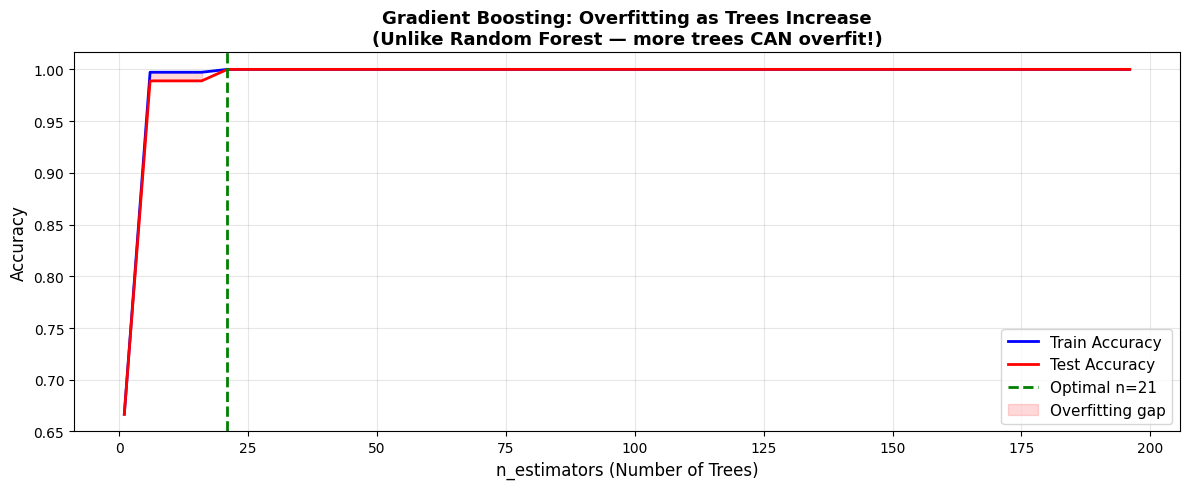

Optimal n_estimators (from test accuracy)   : 21
Optimal n_estimators (from staged_predict)  : 17
Key: staged_predict avoids re-training — use it for efficient early stopping!


In [6]:
# Step 6: Overfitting Analysis — n_estimators vs Train/Test Accuracy
n_range = list(range(1, 201, 5))
train_scores, test_scores = [], []

for n in n_range:
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.2,
                                    max_depth=3, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(X_test)))

best_n = n_range[np.argmax(test_scores)]

# Also use staged_predict for efficient computation
gbm_full = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2,
                                       max_depth=3, random_state=42)
gbm_full.fit(X_train, y_train)
staged_test = [accuracy_score(y_test, pred)
               for pred in gbm_full.staged_predict(X_test)]
optimal_n = np.argmax(staged_test) + 1

plt.figure(figsize=(12, 5))
plt.plot(n_range, train_scores, 'b-', linewidth=2, label='Train Accuracy')
plt.plot(n_range, test_scores,  'r-', linewidth=2, label='Test Accuracy')
plt.axvline(x=best_n, color='green', linestyle='--', linewidth=2,
            label=f'Optimal n={best_n}')
plt.fill_between(n_range, train_scores, test_scores,
                 where=[t>v for t,v in zip(train_scores,test_scores)],
                 alpha=0.15, color='red', label='Overfitting gap')
plt.xlabel('n_estimators (Number of Trees)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Gradient Boosting: Overfitting as Trees Increase\n'
          '(Unlike Random Forest — more trees CAN overfit!)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal n_estimators (from test accuracy)   : {best_n}')
print(f'Optimal n_estimators (from staged_predict)  : {optimal_n}')
print('Key: staged_predict avoids re-training — use it for efficient early stopping!')

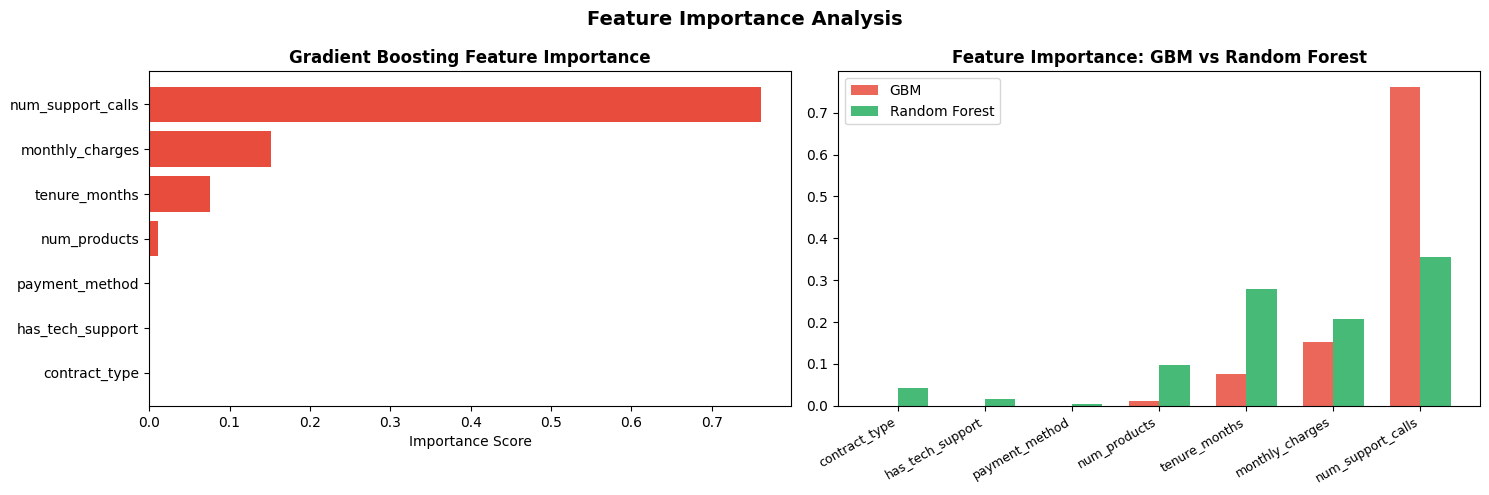

Top 3 features (GBM):
  num_support_calls   : 0.7606  ||||||||||||||||||||||||||||||||||||||
  monthly_charges     : 0.1515  |||||||
  tenure_months       : 0.0761  |||


In [7]:
# Step 7: Feature Importance
imp_df = pd.DataFrame({
    'Feature':    features,
    'GBM':        gbm.feature_importances_,
    'RandomForest': rf.feature_importances_,
}).sort_values('GBM', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# GBM importance
axes[0].barh(imp_df['Feature'], imp_df['GBM'], color='#e74c3c')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Gradient Boosting Feature Importance', fontsize=12, fontweight='bold')

# GBM vs RF side-by-side
x  = np.arange(len(features))
w  = 0.35
axes[1].bar(x - w/2, imp_df['GBM'],          w, label='GBM',           color='#e74c3c', alpha=0.85)
axes[1].bar(x + w/2, imp_df['RandomForest'], w, label='Random Forest', color='#27ae60', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(imp_df['Feature'], rotation=30, ha='right', fontsize=9)
axes[1].set_title('Feature Importance: GBM vs Random Forest', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 3 features (GBM):')
for _, row in imp_df.tail(3).iloc[::-1].iterrows():
    bar = '|' * int(row['GBM'] * 50)
    print(f'  {row["Feature"]:<20}: {row["GBM"]:.4f}  {bar}')

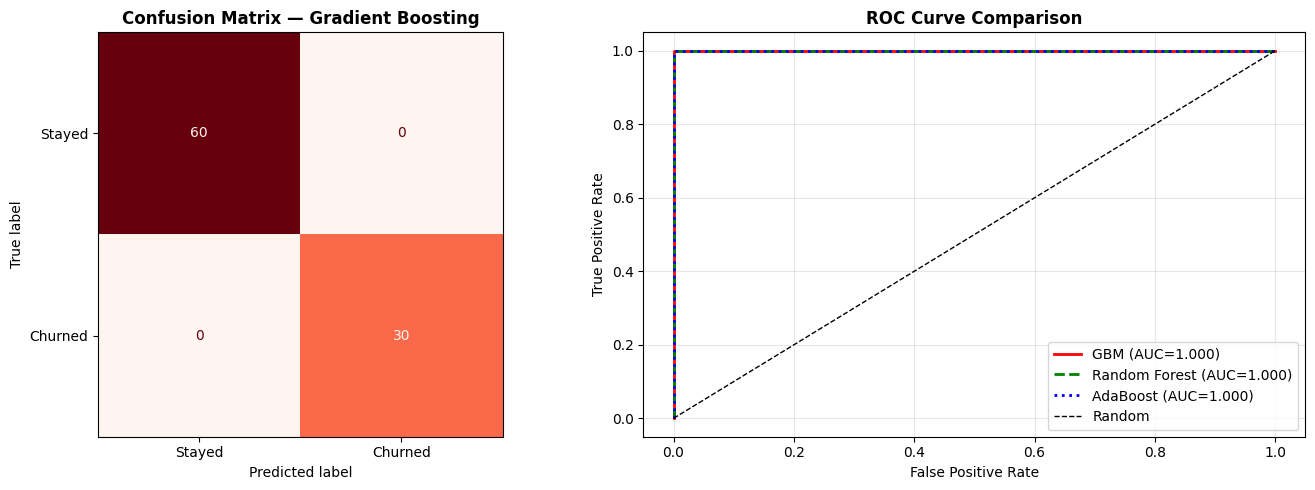

CLASSIFICATION REPORT — Gradient Boosting
              precision    recall  f1-score   support

      Stayed       1.00      1.00      1.00        60
     Churned       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [8]:
# Step 8: Confusion Matrix & ROC Curve
y_pred = gbm.predict(X_test)
y_prob = gbm.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Confusion Matrix — Gradient Boosting', fontsize=12, fontweight='bold')

for name, model, color, ls in [
    ('GBM',           gbm, 'red',   '-'),
    ('Random Forest', rf,  'green', '--'),
    ('AdaBoost',      ada, 'blue',  ':'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    axes[1].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('CLASSIFICATION REPORT — Gradient Boosting')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Stayed','Churned']))

In [9]:
# Step 9: Hyperparameter Tuning — GridSearchCV
param_grid = {
    'n_estimators':   [100, 200],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [3, 5],
    'subsample':      [0.8, 1.0],
    'max_features':   ['sqrt', None],
}

grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                    param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
best = grid.best_estimator_

print('GridSearchCV Results')
print('=' * 50)
print(f'Best Params  : {grid.best_params_}')
print(f'Best CV AUC  : {grid.best_score_:.4f}')
print(f'Test AUC     : {roc_auc_score(y_test, best.predict_proba(X_test)[:,1]):.4f}')
print(f'Test Accuracy: {best.score(X_test, y_test):.4f}')

GridSearchCV Results
Best Params  : {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC  : 1.0000
Test AUC     : 1.0000
Test Accuracy: 1.0000


GBM Regression — Diabetes Dataset (GFG example)
RMSE     : 56.39  (GFG reference: ~56.39)
R2 Score : 0.4370


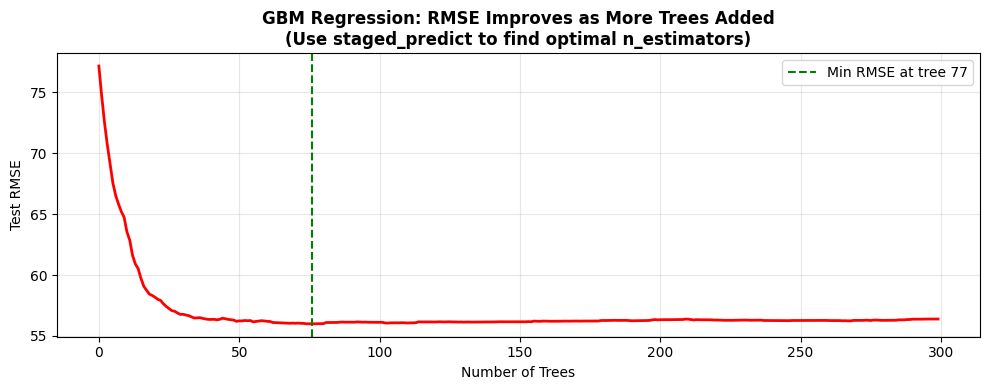

In [10]:
# Step 10: GBM Regression — Diabetes Dataset (GFG example)
from sklearn.metrics import mean_squared_error, r2_score

X_d, y_d = load_diabetes(return_X_y=True)
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_d, y_d, test_size=0.25, random_state=23)

gbr = GradientBoostingRegressor(
    loss='absolute_error', learning_rate=0.1,
    n_estimators=300, max_depth=1,
    random_state=23, max_features=5
)
gbr.fit(X_tr_d, y_tr_d)
y_pr_d = gbr.predict(X_te_d)

rmse = np.sqrt(mean_squared_error(y_te_d, y_pr_d))
r2   = r2_score(y_te_d, y_pr_d)

print('GBM Regression — Diabetes Dataset (GFG example)')
print('=' * 50)
print(f'RMSE     : {rmse:.2f}  (GFG reference: ~56.39)')
print(f'R2 Score : {r2:.4f}')

# Staged prediction — show convergence
staged_rmse = [np.sqrt(mean_squared_error(y_te_d, p))
               for p in gbr.staged_predict(X_te_d)]

plt.figure(figsize=(10, 4))
plt.plot(staged_rmse, 'r-', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Test RMSE')
plt.title('GBM Regression: RMSE Improves as More Trees Added\n'
          '(Use staged_predict to find optimal n_estimators)',
          fontsize=12, fontweight='bold')
plt.axvline(x=np.argmin(staged_rmse), color='green', linestyle='--',
            label=f'Min RMSE at tree {np.argmin(staged_rmse)+1}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Step 11: GBM on GFG's Classification Example — Digits Dataset
from sklearn.datasets import load_digits

X_dig, y_dig = load_digits(return_X_y=True)
X_tr_dig, X_te_dig, y_tr_dig, y_te_dig = train_test_split(
    X_dig, y_dig, test_size=0.25, random_state=23
)

# Exact GFG parameters
gbc_gfg = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    random_state=100, max_features=5
)
gbc_gfg.fit(X_tr_dig, y_tr_dig)
acc = accuracy_score(y_te_dig, gbc_gfg.predict(X_te_dig))

print('GBM Classification — Digits Dataset (GFG code example)')
print('=' * 55)
print(f'Accuracy : {acc:.4f}  (GFG reference: ~0.98)')
print(f'Classes  : {list(range(10))} (digits 0-9)')
print()
print(classification_report(y_te_dig, gbc_gfg.predict(X_te_dig)))

GBM Classification — Digits Dataset (GFG code example)
Accuracy : 0.9778  (GFG reference: ~0.98)
Classes  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (digits 0-9)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.98      0.98      0.98        48
           2       1.00      1.00      1.00        46
           3       1.00      1.00      1.00        41
           4       1.00      0.96      0.98        49
           5       0.94      0.98      0.96        50
           6       1.00      1.00      1.00        41
           7       0.97      0.97      0.97        37
           8       0.94      0.96      0.95        46
           9       0.96      0.95      0.95        55

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [12]:
# Step 12: Live Prediction Demo
new_customers = pd.DataFrame({
    'tenure_months':     [2,  48,  6,  60],
    'monthly_charges':   [95, 55, 110, 45],
    'num_products':      [1,   4,   1,  3],
    'has_tech_support':  [0,   1,   0,  1],
    'contract_type':     [0,   2,   0,  1],
    'payment_method':    [0,   2,   0,  3],
    'num_support_calls': [7,   1,   8,  0],
})
descs = [
    'New, high charges, month-to-month, many complaints',
    'Long-term, low charges, 2-year contract',
    'Short tenure, very high charges, many calls',
    'Long tenure, low charges, 1-year contract',
]

preds = gbm.predict(new_customers)
probs = gbm.predict_proba(new_customers)

print('=' * 65)
print('LIVE CHURN PREDICTION — Gradient Boosting')
print('=' * 65)
for desc, pred, prob in zip(descs, preds, probs):
    label = 'CHURN' if pred == 1 else 'STAY'
    risk  = 'HIGH' if prob[1]>0.7 else 'MEDIUM' if prob[1]>0.4 else 'LOW'
    print(f'\nCustomer: "{desc}"')
    print(f'  Prediction : {label}')
    print(f'  Confidence : Stay={prob[0]:.0%} | Churn={prob[1]:.0%}')
    print(f'  Risk Level : {risk}')

LIVE CHURN PREDICTION — Gradient Boosting

Customer: "New, high charges, month-to-month, many complaints"
  Prediction : CHURN
  Confidence : Stay=0% | Churn=100%
  Risk Level : HIGH

Customer: "Long-term, low charges, 2-year contract"
  Prediction : STAY
  Confidence : Stay=100% | Churn=0%
  Risk Level : LOW

Customer: "Short tenure, very high charges, many calls"
  Prediction : CHURN
  Confidence : Stay=0% | Churn=100%
  Risk Level : HIGH

Customer: "Long tenure, low charges, 1-year contract"
  Prediction : STAY
  Confidence : Stay=100% | Churn=0%
  Risk Level : LOW


---

## Master Cheat Sheet — Everything in One Place

| Concept | One-liner |
|---------|----------|
| Gradient Boosting | Sequential trees, each fits residuals (negative gradient) of previous |
| Boosting (GFG) | Sequential ensemble — reduces BIAS, unlike Bagging which reduces variance |
| Residual | Actual − Predicted — what the next tree targets |
| Pseudo-residual | Negative gradient of loss — generalization of residuals |
| Learning rate η | Shrinkage — scales each tree's contribution to prevent overfitting |
| GFG formula | y_pred = y₁ + η·r₁ + η·r₂ + ... + η·rₙ |
| n_estimators | Number of trees — MORE can overfit (unlike Random Forest) |
| max_depth | Tree depth — keep 3-5; deeper trees overfit |
| subsample | Row fraction per tree — 0.8 reduces variance |
| staged_predict | Get predictions at each boosting stage — use for early stopping |
| GFG: noise | GBM is less sensitive to noise than AdaBoost |
| GFG: sequential | Training is slow — can't parallelize like Random Forest |

---

## Hyperparameter Quick Reference

| Parameter | Default | Tip |
|-----------|---------|-----|
| `n_estimators` | 100 | Use staged_predict to find optimal |
| `learning_rate` | 0.1 | Lower = better; halve it → double n_estimators |
| `max_depth` | 3 | Keep 3-5; GFG uses depth=1-3 |
| `subsample` | 1.0 | Set 0.8 for stochastic GBM (reduces variance) |
| `max_features` | None | 'sqrt' or int — reduces variance |
| `loss` | 'log_loss' | 'squared_error' for regression, 'absolute_error' for robust |
| `warm_start` | False | True = add more trees to existing model |
| `min_samples_leaf` | 1 | Increase on noisy data |

---

## Quick Math

```
Prediction update  :  ŷ_m = ŷ_{m-1} + η × h_m(x)
Pseudo-residual    :  r_im = -[∂L(y_i, ŷ)/∂ŷ]  at ŷ = ŷ_{m-1}
For MSE loss       :  r_im = y_i - ŷ_{m-1}  (simple residual)
Final prediction   :  y_pred = y₁ + η·r₁ + η·r₂ + ... + η·rₙ
```

---

## GBM vs AdaBoost vs Random Forest (GFG)

| Property | Random Forest | AdaBoost | Gradient Boosting |
|----------|--------------|----------|------------------|
| Tree order | Parallel | Sequential | Sequential |
| Error correction | Bootstrap diversity | Re-weight samples | Fit residuals |
| Loss function | Gini/entropy | Classif. error | Any differentiable |
| Noise sensitivity | Low | High | Medium |
| Overfitting risk | Low | Medium | Medium-High |
| Speed | Fast | Medium | Slow |